In [118]:
from pathlib import Path
import sys
import importlib
import os

import json
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import ipywidgets as widgets
from IPython.display import display

# Notebook location expected:
NB_DIR = Path.cwd()
OCGM_DIR = NB_DIR.parent
PROJECT_DIR = OCGM_DIR.parent

for path in [PROJECT_DIR, OCGM_DIR / "scripts"]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import theme.plot_theme as ptheme
import ocean_analysis as oa

# Reload during notebook development
importlib.reload(ptheme)
ptheme.apply_theme()
importlib.reload(oa)


c:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
c:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
c:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)


<module 'ocean_analysis' from 'c:\\Users\\Jelle Gortemaker\\Documents\\Thesis\\OGCM\\scripts\\ocean_analysis.py'>

Red box lat range: 21.50 to 24.50
Red box lon range: -141.60 to -138.40


c:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
c:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
c:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)


(<Figure size 1200x600 with 2 Axes>,
 <GeoAxes: title={'center': 'GPGP Vortex Detection January 2020'}>)

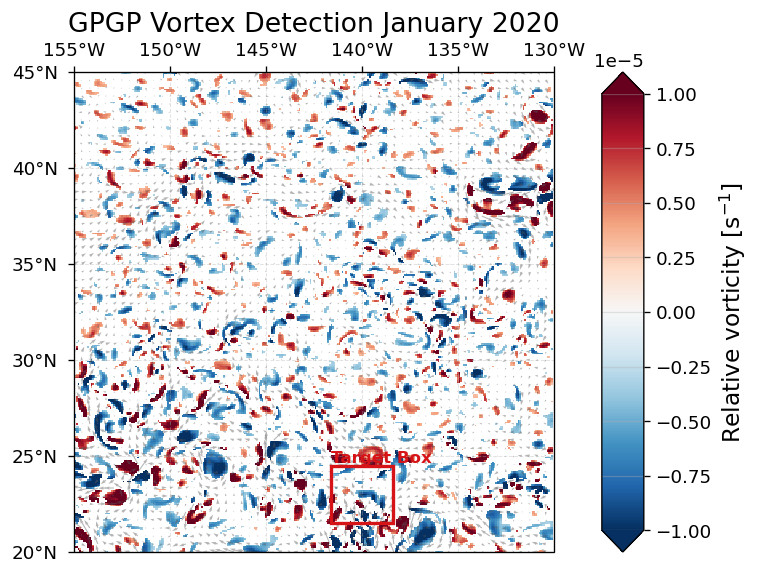

In [119]:
# Fixed symmetric colorbar magnitude
VORT_ABS_MAX = 1.6e-5

# Fixed target plotting domain
MAP_EXTENT = [-155, -130, 20, 45]

# 1. Load Data

# surface_ds = oa.process_glorys_data('../data/input/GPGP_aug2020.nc', averaging_period='1D')
title = f"GPGP Vortex Detection January 2020"

# surface_ds_2021 = oa.process_glorys_data('../data/input/GPGP_aug2021.nc', averaging_period='1D')
# surface_ds_2022 = oa.process_glorys_data('../data/input/GPGP_aug2022.nc', averaging_period='1D')
# surface_ds_2023 = oa.process_glorys_data('../data/input/GPGP_aug2023.nc', averaging_period='1D')
surface_ds = oa.process_glorys_data('../data/input/GPGP_jan2020.nc', averaging_period='1D')
# surface_ds_2021_winter = oa.process_glorys_data('../data/input/GPGP_jan2021.nc', averaging_period='1D')
# surface_ds_2022_winter = oa.process_glorys_data('../data/input/GPGP_jan2022.nc', averaging_period='1D')
# surface_ds_2023_winter = oa.process_glorys_data('../data/input/GPGP_jan2023.nc', averaging_period='1D')


SAVE_JSON = False
JSON_OUTPUT_DIR = Path("../data/processed/ETT")


# 2. Compute Metrics

results = oa.calculate_okubo_weiss(surface_ds)
signed_vort, mask = oa.get_eddy_intensity(results, alpha=0.2)

    
# 3. SELECT TARGET DOMAIN
lat_s = 21.5
lat_n = 24.5
lon_w = -141.6
lon_e = -138.4

print(f"Red box lat range: {lat_s:.2f} to {lat_n:.2f}")
print(f"Red box lon range: {lon_w:.2f} to {lon_e:.2f}")
alpha = 0.2

les_box = oa.get_subdomain(lat_min=lat_s, lon_min=lon_w, lat_max=lat_n, lon_max=lon_e)

ow_results = oa.calculate_okubo_weiss(surface_ds)

signed_intensity, eddy_mask = oa.get_eddy_intensity(
    ow_results,
    alpha=alpha,
)

# 4. Visualize with the Red Rectangle
oa.plot_eddy_intensity(signed_vort, u=surface_ds.uo, v=surface_ds.vo, 
                       title=title,
                       target_box=les_box)


# # 5. Extract statistics strictly inside that box
# box_data = signed_vort.sel(longitude=slice(les_box[0], les_box[1]), 
#                            latitude=slice(les_box[2], les_box[3]))

# print(f"Stats for red box:")
# print(f"Number of eddy core pixels: {int(box_data.notnull().sum())}")

c:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
c:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
c:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
c:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
c:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
c:\

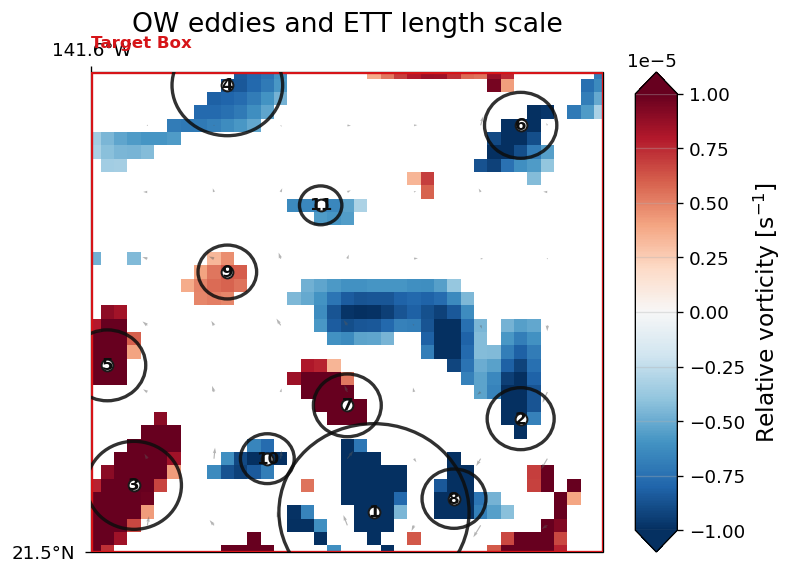

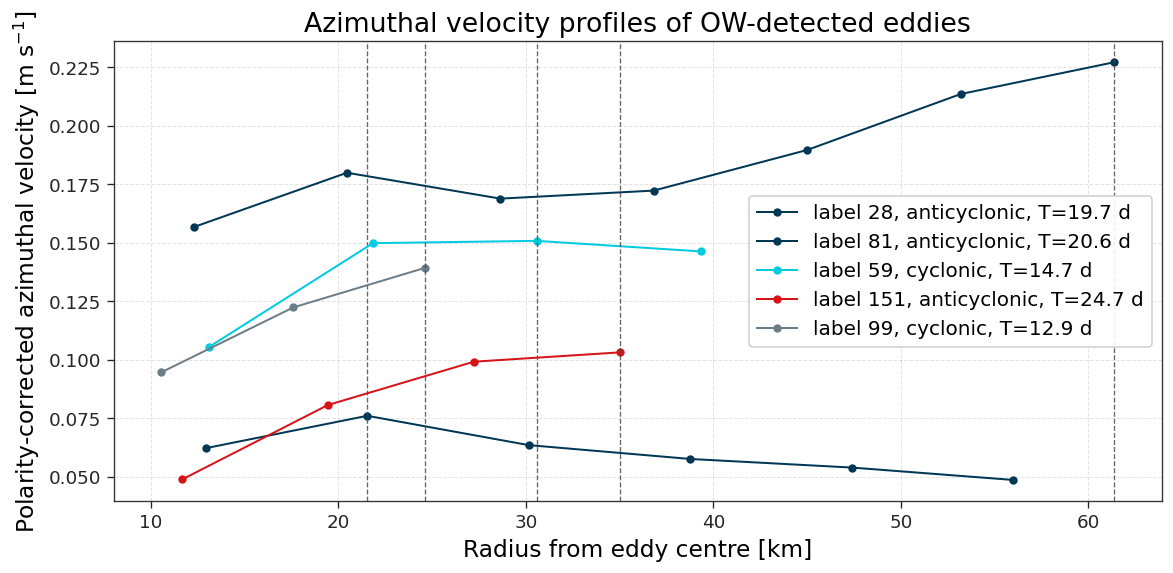

Median GLORYS eddy turnover time: 18.68 days


In [123]:
# ------------------------------------------------------------
# Eddy turnover time from OW-detected GLORYS eddies
# ------------------------------------------------------------
eddy_table, eddy_profiles, eddy_labels = oa.calculate_eddy_turnover_from_ow(
    surface_ds=surface_ds,
    ow_results=ow_results,
    eddy_mask=eddy_mask,
    alpha=0.2,
    target_box=les_box,          # only keep eddies whose centres are inside target box
    min_cells=8,
    n_radial_bins=20,
    search_radius_factor=1.25,
    remove_mean=True,
)

eddy_table


fig, ax, ett_summary = oa.plot_eddy_turnover_map(
    signed_intensity=signed_intensity,
    eddy_table=eddy_table,
    u=surface_ds.uo,
    v=surface_ds.vo,
    title="OW eddies and ETT length scale",
    target_box=les_box,
    extent=les_box,
    vabs=1.0e-5,
    show_radii=True,
)

ett_summary

oa.plot_eddy_turnover_profiles(
    eddy_table=eddy_table,
    profiles=eddy_profiles,
    n=5,
)

if len(eddy_table) == 0:
    print("No OW eddies found inside the target box.")
else:
    representative_T_days = eddy_table["T_eddy_days"].median()

    print(f"Median GLORYS eddy turnover time: {representative_T_days:.2f} days")

In [121]:
# # ============================================================
# # SETTINGS
# # ============================================================

# INPUT_FILE = "../data/input/GPGP_2020.nc"

# START_DATE = "2020-01-01"
# END_DATE = "2020-12-31"

# frames_dir = (
#     rf"C:\Users\Jelle Gortemaker\Downloads\gif_frames_"
#     rf"{START_DATE}_to_{END_DATE}"
# )
# os.makedirs(frames_dir, exist_ok=True)

# MAP_EXTENT = [-155, -130, 20, 45]

# # Colorbar setting
# # Option 1: fixed manual value
# # VORT_ABS_MAX = 8e-6

# # Option 2: automatically determine fixed range from detected vortex-core values
# VORT_PERCENTILE = 98


# # ============================================================
# # DAILY TIME RANGES
# # ============================================================

# dates = pd.date_range(start=START_DATE, end=END_DATE, freq="D")

# time_ranges = [
#     (date.strftime("%Y-%m-%d"), date.strftime("%Y-%m-%d"))
#     for date in dates
# ]

# print(f"Number of daily frames: {len(time_ranges)}")
# print(f"First day: {time_ranges[0][0]}")
# print(f"Last day : {time_ranges[-1][0]}")


# # ============================================================
# # LOAD DAILY DATA
# # ============================================================

# surface_datasets = []
# ow_results = []
# signed_vort_list = []
# mask_list = []

# for tr in time_ranges:
#     surface_ds = oa.process_glorys_data(
#         INPUT_FILE,
#         averaging_period="1D",
#         time_range=tr,
#     )

#     results = oa.calculate_okubo_weiss(surface_ds)
#     signed_vort, mask = oa.get_eddy_intensity(results, alpha=0.2)

#     surface_datasets.append(surface_ds)
#     ow_results.append(results)
#     signed_vort_list.append(signed_vort)
#     mask_list.append(mask)


# # ============================================================
# # SHARED COLORBAR RANGE BASED ON DETECTED VORTEX CORES
# # ============================================================

# vortex_values = np.concatenate([
#     np.ravel(da.values[np.isfinite(da.values)])
#     for da in signed_vort_list
# ])

# if vortex_values.size == 0:
#     raise ValueError("No detected vortex-core values found. Check the OW threshold or input data.")

# VORT_ABS_MAX = np.nanpercentile(np.abs(vortex_values), VORT_PERCENTILE)
# VORT_ABS_MAX = np.ceil(VORT_ABS_MAX / 1e-6) * 1e-6

# print(f"Shared vortex-core colorbar range: ±{VORT_ABS_MAX:.2e} s^-1")


# # ============================================================
# # INTERACTIVE VIEWER
# # ============================================================

# def show_frame(i):
#     fig, ax = oa.plot_eddy_intensity(
#         signed_vort_list[i],
#         u=surface_datasets[i].uo,
#         v=surface_datasets[i].vo,
#         title=f"GPGP Vortex Detection {time_ranges[i][0]}",
#         extent=MAP_EXTENT,
#         vabs=VORT_ABS_MAX,
#     )
#     plt.show()


# widgets.interact(
#     show_frame,
#     i=widgets.IntSlider(
#         min=0,
#         max=len(time_ranges) - 1,
#         step=1,
#         value=0,
#         description="Day index",
#     ),
# )


# # ============================================================
# # SAVE FRAMES FOR GIF
# # ============================================================

# for i, tr in enumerate(time_ranges):
#     fig, ax = oa.plot_eddy_intensity(
#         signed_vort_list[i],
#         u=surface_datasets[i].uo,
#         v=surface_datasets[i].vo,
#         title=f"GPGP Vortex Detection {tr[0]}",
#         extent=MAP_EXTENT,
#         vabs=VORT_ABS_MAX,
#     )

#     frame_path = os.path.join(frames_dir, f"frame_{i:02d}_{tr[0]}.png")

#     fig.savefig(
#         frame_path,
#         dpi=150,
#         facecolor="white",
#         bbox_inches="tight",
#     )
#     plt.close(fig)

# print(f"Frames saved in: {frames_dir}")